# 02 — Ponchon–Savarit: closing the energy balance

McCabe–Thiele draws stages on an $x$–$y$ square by *assuming* constant molal overflow (CMO):
equal molar latent heats and no heat of mixing, so the liquid and vapor flows stay constant
down each section. **Ponchon–Savarit drops that assumption** and works on the
enthalpy–composition (H–x–y) diagram, closing the energy balance exactly through two
*difference points*. This notebook builds the method from scratch and walks four systems up an
escalating ladder: the two methods **agree** where CMO holds (benzene–toluene), **drift apart**
where it wobbles (methanol–water), **break** where the latent heats are badly unequal — for
acetone–water at design-heuristic reflux McCabe–Thiele under-counts stages by ~40% and calls an
infeasible column feasible — and finish on the classic showcase, **ammonia–water**, where the
construction is stepped on a real reference chart built from the Pátek–Klomfar correlation of
the experimental data behind the Bošnjaković / Ibrahim–Klein diagrams.

## Setup (optional)

The published wheels install everything needed. Uncomment to install in a fresh environment —
left commented so the notebook executes top-to-bottom without touching your environment.

In [1]:
# %pip install --upgrade stages-thermo vle-thermo matplotlib

## Context — the method

> *"…the enthalpy–concentration diagram, on which the difference point fixes both the
> material and the heat balance, so that the number of theoretical plates is stepped off
> directly."* — after Ponchon (*La Technique Moderne* **1921**) and Savarit
> (*Arts et Métiers* **1922**); implementation-level treatment in Seader, Henley & Roper, Ch. 7.

Full derivation: [`docs/theory/ponchon-savarit.md`](../docs/theory/ponchon-savarit.md).

The diagram carries two saturation curves versus composition: saturated **liquid** enthalpy
$h_L(x)$ and saturated **vapor** enthalpy $H_V(y)$, joined at each $x$ by a **tie line** to the
equilibrium vapor $y^\ast(x)$. The energy balance rides on two **difference points** (poles):

$$\Delta_D = \left(x_D,\ Q_D^{\prime}\right), \qquad Q_D^{\prime} = H_{V1} + R\,(H_{V1} - h_{L0}),$$

$$\Delta_B = \left(x_B,\ Q_B^{\prime}\right), \qquad \text{with } \Delta_D,\ F,\ \Delta_B \text{ collinear}.$$

The reflux ratio $R$ sets the height of $\Delta_D$; the overall balance makes the feed point
$F = (z_F, h_F)$ collinear with the two poles, which fixes $\Delta_B$. Stepping mirrors
McCabe–Thiele with two substitutions: the equilibrium step becomes a **tie line**
($x_n = x^\ast(y_n)$, the same inverse), and the operating step becomes a **pole line** — the
vapor $y_{n+1}$ is where the straight line through the section's pole and the liquid point
$(x_n, h_L(x_n))$ cuts the saturated-vapor curve.

**Why it matters:** where the molar latent heats are unequal or the heat of mixing is large,
CMO fails, and Ponchon–Savarit gives the right stage count *and* the condenser/reboiler duties
— which McCabe–Thiele cannot compute at all.

## What was built in this milestone

Everything here is Rust (`engine/src/`), exposed through PyO3 into the `stages` package:

- **`stages.ThermoSystem`** (`thermo.rs`) — gains **`nrtl(names, a12, a21, alpha)`** (the γ-φ
  NRTL model, general aqueous-organic infrastructure) and **`phase_enthalpy(t, p, comp, phase)`**
  → molar enthalpy [kJ/kmol] of a liquid or vapor, wrapping vle-thermo 0.11's γ-φ / φ-φ
  enthalpy route. One reference state (`t_ref`/`p_ref`) is set once for the whole column.
- **`stages.EnthalpyCurve`** (`binary/equilibrium.rs`) — the H–x–y curve. `from_thermo(system,
  P, n)` **computes** it (route a); `from_points(x, y, h_liq, h_vap, t, P)` **feeds reference
  data** (route b).
- **`stages.ponchon_savarit(curve, x_D, x_B, z_F, R, q, condenser)`** (`binary/ponchon_savarit.rs`)
  — the full construction, returning stages, the poles $\Delta_D$/$\Delta_B$, the per-mole-feed
  duties $Q_C/F$ and $Q_R/F$, and the tie lines.
- **`stages.plotting`** — `plot_hxy` and `plot_ponchon_savarit` draw the H–x–y frame and the
  stepped construction.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import stages
from stages import plotting
from vle.units import Q_

%matplotlib inline
print(f"stages-thermo {stages.__version__}")

P = Q_(1, "atm").to("kPa").magnitude   # 101.325 kPa — canonical engine units are kPa/K
print(f"column pressure: {P:.3f} kPa")

stages-thermo 0.2.0
column pressure: 101.325 kPa


## Worked example 1 — benzene–toluene: the consistency check

Benzene–toluene is near-ideal: nearly equal molar latent heats, negligible heat of mixing.
CMO is a good assumption, so **Ponchon–Savarit and McCabe–Thiele should agree**. We run both on
the same spec ($x_D = 0.95$, $x_B = 0.05$, $z_F = 0.50$, saturated-liquid feed, $R = 1.5\,R_{min}$)
and compare.

In [3]:
sys_bt = stages.ThermoSystem.peng_robinson(["benzene", "toluene"])
ec_bt = stages.EnthalpyCurve.from_thermo(sys_bt, P, n_points=401)

# The plain equilibrium curve on the same grid, for McCabe-Thiele.
eq_bt = stages.EquilibriumCurve.from_points(list(ec_bt.x), list(ec_bt.y), list(ec_bt.t), P)
r_min = stages.rmin(eq_bt, 0.95, 0.05, 0.50).r_min
R = 1.5 * r_min

ps_bt = stages.ponchon_savarit(ec_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)
mt_bt = stages.mccabe_thiele(eq_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)

print(f"R_min = {r_min:.4f},  R = {R:.4f}")
print(f"Ponchon-Savarit : N = {ps_bt.n_stages:.3f} stages, feed stage {ps_bt.feed_stage}")
print(f"McCabe-Thiele   : N = {mt_bt.n_stages:.3f} stages, feed stage {mt_bt.feed_stage}")
print(f"duties (P-S): Q_C/F = {ps_bt.q_condenser:,.0f}, Q_R/F = {ps_bt.q_reboiler:,.0f} kJ/kmol feed")

R_min = 1.1628,  R = 1.7442
Ponchon-Savarit : N = 12.886 stages, feed stage 6
McCabe-Thiele   : N = 12.220 stages, feed stage 6
duties (P-S): Q_C/F = 42,112, Q_R/F = 42,702 kJ/kmol feed


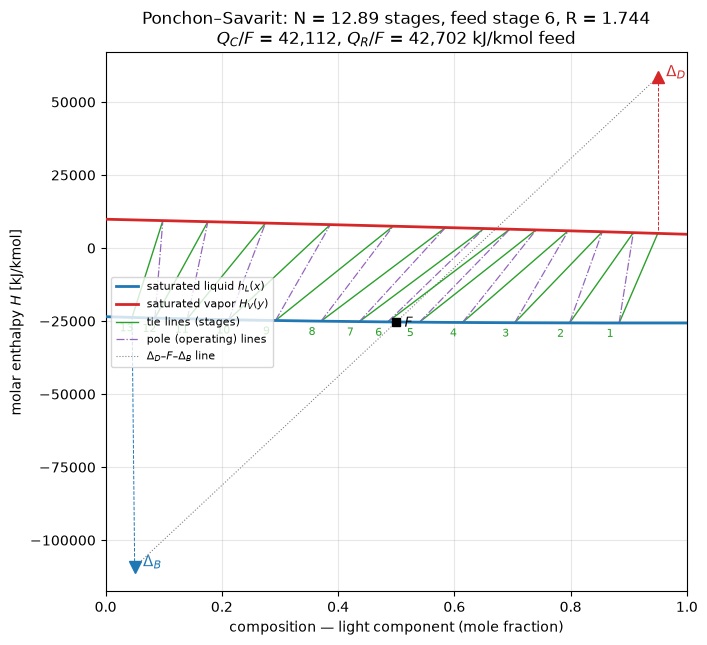

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 7))
plotting.plot_ponchon_savarit(ps_bt, ec_bt, ax=ax)
plt.show()

In [5]:
# Pinned expectations (a regression here means a real behavioral change).
assert abs(mt_bt.n_stages - 12.22) < 0.15, mt_bt.n_stages   # reproduces the M1-pinned value
assert abs(ps_bt.n_stages - 12.89) < 0.25, ps_bt.n_stages
assert ps_bt.feed_stage == mt_bt.feed_stage == 6
# Near-ideal: the two methods agree within ~1 stage.
assert abs(ps_bt.n_stages - mt_bt.n_stages) < 1.0
print("OK — Ponchon-Savarit and McCabe-Thiele agree for near-ideal benzene-toluene.")

OK — Ponchon-Savarit and McCabe-Thiele agree for near-ideal benzene-toluene.


## Worked example 2 — methanol–water: the CMO error appears

Methanol–water is nonideal and, more to the point here, its molar latent heats differ by
about 13% (methanol ≈ 35,300, water ≈ 40,700 kJ/kmol), so CMO is imperfect and the two
methods **diverge**. Same spec, van Laar γ-φ liquid (the vle Chapter IV parameters
$A_{12} = 0.5853$, $A_{21} = 0.3458$). Note the van Laar constants are
temperature-independent, so this model's excess enthalpy is exactly zero — the gap below is
driven by the latent-heat mismatch and sensible heat, not by a modelled heat of mixing.

In [6]:
sys_mw = stages.ThermoSystem.van_laar(["methanol", "water"], 0.5853, 0.3458)
ec_mw = stages.EnthalpyCurve.from_thermo(sys_mw, P, n_points=401)
eq_mw = stages.EquilibriumCurve.from_points(list(ec_mw.x), list(ec_mw.y), list(ec_mw.t), P)

R2 = 1.5 * stages.rmin(eq_mw, 0.95, 0.05, 0.50).r_min
ps_mw = stages.ponchon_savarit(ec_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R2)
mt_mw = stages.mccabe_thiele(eq_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R2)

gap = ps_mw.n_stages - mt_mw.n_stages
print(f"Ponchon-Savarit : N = {ps_mw.n_stages:.3f}")
print(f"McCabe-Thiele   : N = {mt_mw.n_stages:.3f}")
print(f"CMO error (P-S - M-T) = {gap:+.3f} stages")
print(f"duties (P-S): Q_C/F = {ps_mw.q_condenser:,.0f}, Q_R/F = {ps_mw.q_reboiler:,.0f} kJ/kmol feed")

Ponchon-Savarit : N = 8.369
McCabe-Thiele   : N = 7.965
CMO error (P-S - M-T) = +0.404 stages
duties (P-S): Q_C/F = 34,789, Q_R/F = 35,055 kJ/kmol feed


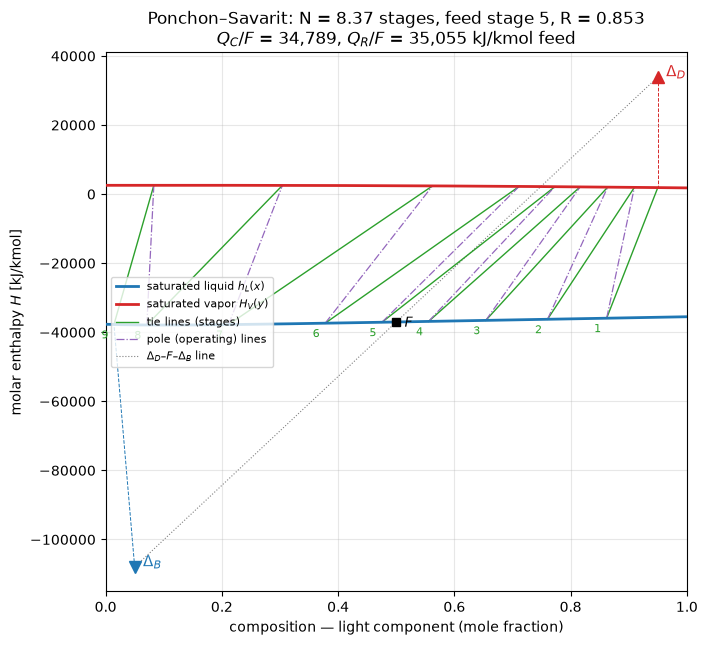

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 7))
plotting.plot_ponchon_savarit(ps_mw, ec_mw, ax=ax)
plt.show()

In [8]:
# Unequal latent heats make CMO under-count: P-S needs more stages than M-T here.
assert abs(mt_mw.n_stages - 7.97) < 0.2, mt_mw.n_stages
assert abs(ps_mw.n_stages - 8.37) < 0.2, ps_mw.n_stages
assert ps_mw.n_stages > mt_mw.n_stages, "expected a CMO-error gap"
print(f"OK — CMO under-counts by {gap:.2f} stages for methanol-water.")

OK — CMO under-counts by 0.40 stages for methanol-water.


## Worked example 3 — acetone–water: when the CMO error becomes a design failure

Acetone condenses at ≈ 30,800 kJ/kmol; vaporizing water takes ≈ 40,200. At that 1.31 ratio a
kmol of condensing vapor can no longer boil up a kmol of liquid, the molar flows *must* change
along each section, and the real operating relation on the $x$–$y$ square is a **curve**, not
McCabe–Thiele's straight line. The van Laar constants used here are temperature-independent,
so the model's heat of mixing is exactly zero — everything that follows comes from the
latent-heat mismatch and sensible heat alone.

Where it bites is **near the pinch**. At the textbook design heuristic
$R = 1.1$–$1.2 \times R_{min}$ the operating line runs close to the equilibrium curve, and a
few-percent error in the internal flows is amplified into a huge error in the stage count — or
into a column that cannot meet spec at all. Watch $x_D = 0.90$, $x_B = 0.05$, $z_F = 0.30$
(saturated-liquid feed):

In [9]:
sys_ac = stages.ThermoSystem.van_laar(["acetone", "water"], 2.0400, 1.5019)
ec_ac = stages.EnthalpyCurve.from_thermo(sys_ac, P, n_points=401)
eq_ac = stages.EquilibriumCurve.from_points(list(ec_ac.x), list(ec_ac.y), list(ec_ac.t), P)

lam_water = ec_ac.h_vap[0] - ec_ac.h_liq[0]      # tie-line gap at x = 0
lam_acetone = ec_ac.h_vap[-1] - ec_ac.h_liq[-1]  # tie-line gap at x = 1
print(f"latent heats: water {lam_water:,.0f}, acetone {lam_acetone:,.0f} kJ/kmol "
      f"(ratio {lam_water / lam_acetone:.2f})")

spec_ac = dict(x_distillate=0.90, x_bottoms=0.05, z_feed=0.30)
rmin_mt = stages.rmin(eq_ac, 0.90, 0.05, 0.30)

# The energy-exact minimum reflux: bisect for the smallest R at which the
# Ponchon-Savarit staircase still reaches x_B. Below it a pole line no longer
# cuts the saturated-vapor curve -- the construction pinches.
def ps_feasible(R):
    try:
        stages.ponchon_savarit(ec_ac, reflux=R, **spec_ac)
        return True
    except RuntimeError:
        return False

lo, hi = rmin_mt.r_min, 2.0 * rmin_mt.r_min
assert not ps_feasible(lo) and ps_feasible(hi)
for _ in range(30):
    mid = 0.5 * (lo + hi)
    lo, hi = (lo, mid) if ps_feasible(mid) else (mid, hi)
rmin_ps = hi

print(f"minimum reflux:  CMO (M-T) {rmin_mt.r_min:.4f}   energy-exact (P-S) {rmin_ps:.4f}"
      f"   ->  CMO underestimates R_min by {100 * (rmin_ps / rmin_mt.r_min - 1):.0f}%")

print("\n  R / Rmin_MT        R      M-T N     P-S N")
for factor in (1.1, 1.2, 1.3, 1.5, 2.0):
    R = factor * rmin_mt.r_min
    mt_n = stages.mccabe_thiele(eq_ac, reflux=R, **spec_ac).n_stages
    try:
        ps_n = f"{stages.ponchon_savarit(ec_ac, reflux=R, **spec_ac).n_stages:9.2f}"
    except RuntimeError:
        ps_n = "  PINCHED (infeasible)"
    print(f"     {factor:.1f}       {R:8.4f}  {mt_n:8.2f} {ps_n}")

latent heats: water 40,233, acetone 30,767 kJ/kmol (ratio 1.31)
minimum reflux:  CMO (M-T) 0.2247   energy-exact (P-S) 0.2477   ->  CMO underestimates R_min by 10%

  R / Rmin_MT        R      M-T N     P-S N
     1.1         0.2472     13.92   PINCHED (infeasible)
     1.2         0.2697      9.93     14.00
     1.3         0.2922      8.46     10.18
     1.5         0.3371      6.79      7.79
     2.0         0.4495      5.27      5.70


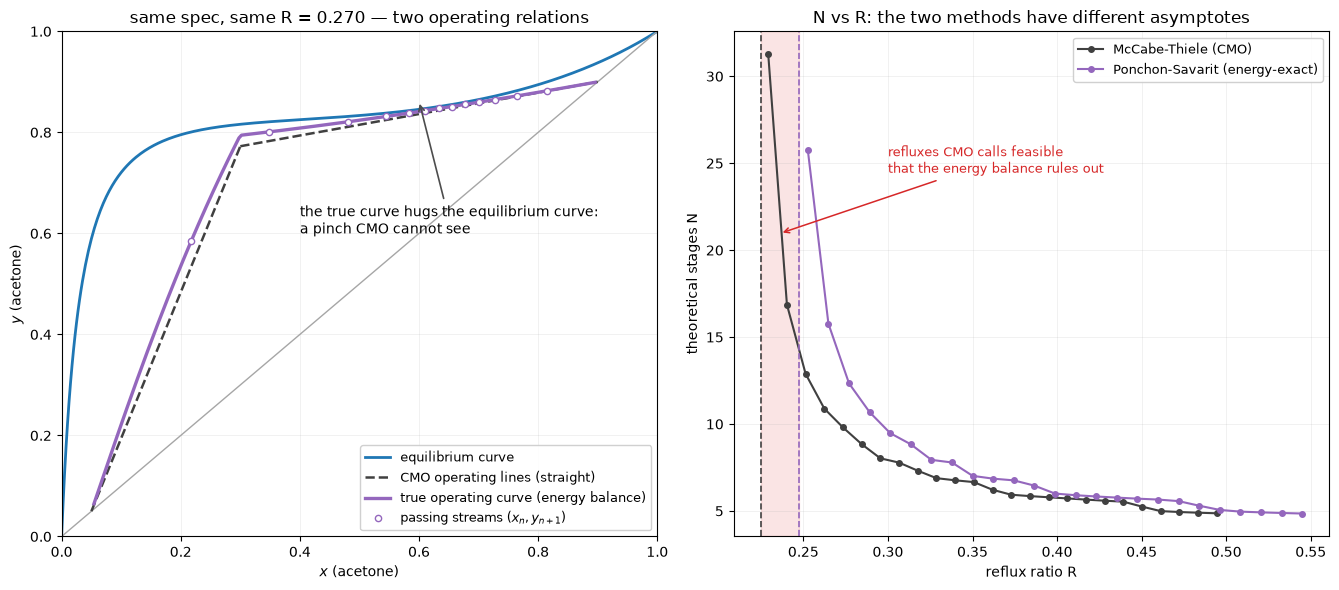

In [10]:
# The mechanism, drawn. Left: the x-y square M-T sees, with the true energy-balanced
# operating curve overlaid. Right: stages vs reflux for both methods.
R12 = 1.2 * rmin_mt.r_min
ps_ac = stages.ponchon_savarit(ec_ac, reflux=R12, **spec_ac)
mt_ac = stages.mccabe_thiele(eq_ac, reflux=R12, **spec_ac)

def bisect(g, lo, hi, iters=80):
    glo = g(lo)
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        gm = g(mid)
        if glo * gm <= 0:
            hi = mid
        else:
            lo, glo = mid, gm
    return 0.5 * (lo + hi)

def true_operating_curve(ps, ec, n=200):
    """Sweep the pole lines: for each liquid point (x, h_L) the passing vapor y is
    where the straight line through the section's pole cuts the saturated-vapor curve
    (the same collinearity the stepper solves, docs/theory/ponchon-savarit.md)."""
    s = ps.spec
    xs, hls = np.array(ec.x), np.array(ec.h_liq)
    yss, hvs = np.array(ec.y), np.array(ec.h_vap)
    tx, ty = [], []
    for xl in np.linspace(s.x_bottoms, s.x_distillate, n):
        xp, hp = ps.delta_d if xl >= s.z_feed else ps.delta_b
        hl = np.interp(xl, xs, hls)
        g = lambda y: (xl - xp) * (np.interp(y, yss, hvs) - hp) - (hl - hp) * (y - xp)
        if g(xl + 1e-9) * g(1.0 - 1e-9) > 0:
            continue  # at/below the pinch nothing passes
        tx.append(xl)
        ty.append(bisect(g, xl + 1e-9, 1.0 - 1e-9))
    return np.array(tx), np.array(ty)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 6))

ax1.plot(ec_ac.x, ec_ac.y, color="tab:blue", lw=2, label="equilibrium curve")
ax1.plot([0, 1], [0, 1], color="0.65", lw=1)
xi = np.linspace(0.30, 0.90, 40)
ax1.plot(xi, mt_ac.rectifying.slope * xi + mt_ac.rectifying.intercept, "--", color="0.25", lw=1.8)
xi = np.linspace(0.05, 0.30, 40)
ax1.plot(xi, mt_ac.stripping.slope * xi + mt_ac.stripping.intercept, "--", color="0.25",
         lw=1.8, label="CMO operating lines (straight)")
tx, ty = true_operating_curve(ps_ac, ec_ac)
ax1.plot(tx, ty, color="tab:purple", lw=2.4, label="true operating curve (energy balance)")
xs_ = [s.x for s in ps_ac.stages]
ys_ = [s.y for s in ps_ac.stages]
ax1.plot(xs_[:-1], ys_[1:], "o", color="tab:purple", ms=4.5, mfc="white",
         label="passing streams $(x_n, y_{n+1})$")
ax1.annotate("the true curve hugs the equilibrium curve:\na pinch CMO cannot see",
             xy=(0.60, 0.862), xytext=(0.40, 0.60), fontsize=10,
             arrowprops=dict(arrowstyle="->", color="0.3", lw=1.2))
ax1.set(xlim=(0, 1), ylim=(0, 1), xlabel="$x$ (acetone)", ylabel="$y$ (acetone)",
        title=f"same spec, same R = {R12:.3f} — two operating relations")
ax1.grid(alpha=0.25, lw=0.5)
ax1.legend(loc="lower right", fontsize=9, framealpha=0.92)

factors = np.linspace(1.02, 2.2, 25)
rs_mt = [f * rmin_mt.r_min for f in factors]
ns_mt = [stages.mccabe_thiele(eq_ac, reflux=r, **spec_ac).n_stages for r in rs_mt]
rs_ps, ns_ps = [], []
for f in factors:
    r = f * rmin_ps
    try:
        ns_ps.append(stages.ponchon_savarit(ec_ac, reflux=r, **spec_ac).n_stages)
        rs_ps.append(r)
    except RuntimeError:
        pass
ax2.plot(rs_mt, ns_mt, "o-", ms=4, color="0.25", label="McCabe-Thiele (CMO)")
ax2.plot(rs_ps, ns_ps, "o-", ms=4, color="tab:purple", label="Ponchon-Savarit (energy-exact)")
ax2.axvline(rmin_mt.r_min, ls="--", color="0.25", lw=1.2)
ax2.axvline(rmin_ps, ls="--", color="tab:purple", lw=1.2)
ax2.axvspan(rmin_mt.r_min, rmin_ps, color="tab:red", alpha=0.12)
ax2.annotate("refluxes CMO calls feasible\nthat the energy balance rules out",
             xy=(0.5 * (rmin_mt.r_min + rmin_ps), 0.60), xycoords=ax2.get_xaxis_transform(),
             xytext=(0.30, 0.72), textcoords=ax2.get_xaxis_transform(),
             fontsize=9, color="tab:red",
             arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.1))
ax2.set(xlabel="reflux ratio R", ylabel="theoretical stages N",
        title="N vs R: the two methods have different asymptotes")
ax2.grid(alpha=0.25, lw=0.5)
ax2.legend(fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.show()

In [11]:
# Pinned expectations for the design-failure case.
assert abs(rmin_mt.r_min - 0.2247) < 0.005, rmin_mt.r_min
assert abs(rmin_ps - 0.2477) < 0.005, rmin_ps
assert rmin_ps > 1.08 * rmin_mt.r_min            # CMO underestimates R_min by ~10%
assert not ps_feasible(1.1 * rmin_mt.r_min)      # the "1.1 x Rmin" design cannot work
assert abs(mt_ac.n_stages - 9.93) < 0.2, mt_ac.n_stages
assert abs(ps_ac.n_stages - 14.00) < 0.3, ps_ac.n_stages
assert ps_ac.n_stages > 1.35 * mt_ac.n_stages    # ~40% under-count at 1.2 x Rmin(CMO)
print(f"OK — at R = 1.2 Rmin(CMO): M-T {mt_ac.n_stages:.2f} vs P-S {ps_ac.n_stages:.2f} stages "
      f"({100 * (ps_ac.n_stages / mt_ac.n_stages - 1):.0f}% under-counted); "
      f"at 1.1 Rmin(CMO) the real column pinches.")

OK — at R = 1.2 Rmin(CMO): M-T 9.93 vs P-S 14.00 stages (41% under-counted); at 1.1 Rmin(CMO) the real column pinches.


**The lesson, spelled out.** Nothing about acetone–water is exotic — no azeotrope in this
range, everyday chemicals, a modest split. Yet at the standard design heuristic McCabe–Thiele
(1) certifies a reflux at which the real column pinches — the true $R_{min}$ is ~10% above
what CMO believes — and (2) at $R = 1.2 R_{min}^{CMO}$ delivers a design ~40% short on
stages. The left panel shows the mechanism: the energy balance bends the true operating curve
toward the equilibrium curve, closing a pinch the straight CMO line cannot see; the right
panel shows the consequence: the two methods do not even share a feasible region. All of it
from a 1.31 latent-heat ratio, with zero heat of mixing in the model. **This is why an
energy-exact method exists.**

## Worked example 4 — ammonia–water: computed chart vs reference chart

Ammonia–water is *the* historical Ponchon–Savarit showcase: molar latent heats of ≈ 23,300
(NH₃) vs ≈ 40,700 kJ/kmol (H₂O) — ratio 1.7 — *plus* an enormous exothermic heat of mixing.
But there is a subtlety — the classic chart (Merkel–Bošnjaković; modern refinements
Ibrahim–Klein 1993, Tillner-Roth 1998) is a **data artifact** built from experimental VLE +
calorimetry, not an on-the-fly model. So we step the construction **two ways** (full
discussion in [`docs/theory/ponchon-savarit.md`](../docs/theory/ponchon-savarit.md)):

- **Route (a)** — *compute* the H–x–y chart from an NRTL γ-φ model and step off stages.
- **Route (b)** — *feed digitized reference data* through `EnthalpyCurve.from_points` and run
  the same construction on the real chart.

### Route (a): the NRTL-computed chart

NRTL parameters for NH₃(1)–H₂O(2), carried over from vle-thermo's Milestone 14 (α = 0.2, the
recommended ammonia value; interaction energies chosen to reproduce the hallmark **negative
deviation** and **exothermic mixing**; magnitudes illustrative, not a certified regression).

In [12]:
sys_aw = stages.ThermoSystem.nrtl(["ammonia", "water"], a12=-1800.0, a21=-1200.0, alpha=0.2)
ec_a = stages.EnthalpyCurve.from_thermo(sys_aw, P, n_points=121)

x = np.array(ec_a.x); y = np.array(ec_a.y); T = np.array(ec_a.t)
print(f"bubble-T range: {T.min():.1f} - {T.max():.1f} K  (ammonia is very volatile)")

# Easy split (huge relative volatility): x_D = 0.98, x_B = 0.02, z_F = 0.30, R = 1.5.
spec = dict(x_distillate=0.98, x_bottoms=0.02, z_feed=0.30, reflux=1.5)
ps_a = stages.ponchon_savarit(ec_a, **spec)
print(f"route (a) NRTL : N = {ps_a.n_stages:.3f}, feed {ps_a.feed_stage}, "
      f"Q_C/F = {ps_a.q_condenser:,.0f}, Q_R/F = {ps_a.q_reboiler:,.0f} kJ/kmol feed")

bubble-T range: 239.7 - 373.6 K  (ammonia is very volatile)


route (a) NRTL : N = 2.458, feed 1, Q_C/F = 19,254, Q_R/F = 24,663 kJ/kmol feed


### Route (b): the reference chart, digitized

The reference points come from the **Pátek–Klomfar (1995) correlation** (*Int. J. Refrig.*
18(4), 228–234): five explicit functions least-squares fitted to the experimental VLE and
calorimetric data for NH₃–H₂O — the same body of data behind the Bošnjaković chart and the
Ibrahim–Klein (1993) ASHRAE formulation — published precisely so that saturation properties
can be regenerated quickly without re-solving a Gibbs-energy model. We implement the four
functions the H–x–y diagram needs straight from the paper's coefficient tables — bubble
temperature $T(p, x)$, equilibrium vapor composition $y(p, x)$, saturated-liquid enthalpy
$h_L(T, x)$ and saturated-vapor enthalpy $H_V(T, y)$ — and verify them against IAPWS/NIST
pure-component values before trusting them.

Conventions to watch: compositions are ammonia **mole** fractions; the paper's enthalpies are
kJ/kg (converted to kJ/kmol below with the mixture molar mass); the datum is $h_L = 0$ for
saturated liquid at 273.16 K, which differs from route (a)'s reference state. That mismatch
is harmless — stage count *and* duties are invariant to any per-component linear shift of the
enthalpy datum, because every quantity the construction uses is a difference read at fixed
composition.

In [13]:
# Patek & Klomfar (1995), Int. J. Refrig. 18(4), 228-234. Each correlation is
#   value = scale * sum_i  a_i * u^m_i * v^n_i
# over a published coefficient table. x, y are NH3 MOLE fractions; p in MPa; T in K.
def _pk(table, u, v, scale):
    m, n, a = table[:, 0][:, None], table[:, 1][:, None], table[:, 2][:, None]
    return scale * np.sum(a * u**m * v**n, axis=0)

# columns: m_i, n_i, a_i
PK_TBUB = np.array([  # Table 1 -- T_bub(p, x): u = 1 - x, v = ln(2 MPa / p), scale 100 K
    [0, 0, 0.322302e1], [0, 1, -0.384206e0], [0, 2, 0.460965e-1], [0, 3, -0.378945e-2],
    [0, 4, 0.135610e-3], [1, 0, 0.487755e0], [1, 1, -0.120108e0], [1, 2, 0.106154e-1],
    [2, 3, -0.533589e-3], [4, 0, 0.785041e1], [5, 0, -0.115941e2], [5, 1, -0.523150e-1],
    [6, 0, 0.489596e1], [13, 1, 0.421059e-1]])
PK_TDEW = np.array([  # Table 2 -- T_dew(p, y): u = (1-y)^(1/4), v = ln(2 MPa / p), scale 100 K
    [0, 0, 0.324004e1], [0, 1, -0.395920e0], [0, 2, 0.435624e-1], [0, 3, -0.218943e-2],
    [1, 0, -0.143526e1], [1, 1, 0.105256e1], [1, 2, -0.719281e-1], [2, 0, 0.122362e2],
    [2, 1, -0.224368e1], [3, 0, -0.201780e2], [3, 1, 0.110834e1], [4, 0, 0.145399e2],
    [4, 2, 0.644312e0], [5, 0, -0.221246e1], [5, 2, -0.756266e0], [6, 0, -0.135529e1],
    [7, 2, 0.183541e0]])
PK_Y = np.array([     # Table 3 -- y(p, x): u = p / 2 MPa, v = x^(1/3); y = 1 - exp(ln(1-x) * sum)
    [0, 0, 1.98022017e1], [0, 1, -1.18092669e1], [0, 6, 2.77479980e1], [0, 7, -2.88634277e1],
    [1, 0, -5.91616608e1], [2, 1, 5.78091305e2], [2, 2, -6.21736743e0], [3, 2, -3.42198402e3],
    [4, 3, 1.19403127e4], [5, 4, -2.45413777e4], [6, 5, 2.91591865e4], [7, 6, -1.84782290e4],
    [7, 7, 2.34819434e1], [8, 7, 4.80310617e3]])
PK_HL = np.array([    # Table 4 -- h_L(T, x): u = T/273.16 K - 1, v = x, scale 100 kJ/kg
    [0, 1, -0.761080e1], [0, 4, 0.256905e2], [0, 8, -0.247092e3], [0, 9, 0.325952e3],
    [0, 12, -0.158854e3], [0, 14, 0.619084e2], [1, 0, 0.114314e2], [1, 1, 0.118157e1],
    [2, 1, 0.284179e1], [3, 3, 0.741609e1], [5, 3, 0.891844e3], [5, 4, -0.161309e4],
    [5, 5, 0.622106e3], [6, 2, -0.207588e3], [6, 4, -0.687393e1], [8, 0, 0.350716e1]])
PK_HV = np.array([    # Table 5 -- h_V(T, y): u = 1 - T/324 K, v = (1-y)^(1/4), scale 1000 kJ/kg
    [0, 0, 0.128827e1], [1, 0, 0.125247e0], [2, 0, -0.208748e1], [3, 0, 0.217696e1],
    [0, 2, 0.235687e1], [1, 2, -0.886987e1], [2, 2, 0.102635e2], [3, 2, -0.237440e1],
    [0, 3, -0.670515e1], [1, 3, 0.164508e2], [2, 3, -0.936849e1], [0, 4, 0.842254e1],
    [1, 4, -0.858807e1], [0, 5, -0.277049e1], [4, 6, -0.961248e0], [2, 7, 0.988009e0],
    [1, 10, 0.308482e0]])
# (Published transcriptions of Table 5 disagree in the 4th digit of rows 9 and 13; the two
#  variants differ by < 4 kJ/kg -- far below the correlation's own fit scatter.)

def pk_t_bubble(p_mpa, x):
    """Bubble temperature [K] at p [MPa], liquid NH3 mole fraction x."""
    return _pk(PK_TBUB, 1.0 - x, np.log(2.0 / p_mpa), 100.0)

def pk_t_dew(p_mpa, y):
    """Dew temperature [K] at p [MPa], vapor NH3 mole fraction y."""
    return _pk(PK_TDEW, (1.0 - y) ** 0.25, np.log(2.0 / p_mpa), 100.0)

def pk_y(p_mpa, x):
    """Equilibrium vapor NH3 mole fraction over liquid x at p [MPa]."""
    x = np.minimum(np.asarray(x, dtype=float), 1.0 - 1e-12)
    return 1.0 - np.exp(np.log1p(-x) * _pk(PK_Y, p_mpa / 2.0, np.cbrt(x), 1.0))

def pk_h_liq(t_k, x):
    """Saturated-liquid enthalpy [kJ/kg] at T [K], NH3 mole fraction x."""
    return _pk(PK_HL, t_k / 273.16 - 1.0, x, 100.0)

def pk_h_vap(t_k, y):
    """Saturated-vapor enthalpy [kJ/kg] at T [K], NH3 mole fraction y."""
    return _pk(PK_HV, 1.0 - t_k / 324.0, (1.0 - y) ** 0.25, 1000.0)

M_NH3, M_H2O = 17.031, 18.015  # kg/kmol
def mix_molar_mass(z):
    """Mixture molar mass [kg/kmol] at NH3 mole fraction z."""
    return z * M_NH3 + (1.0 - z) * M_H2O

# Verify against IAPWS / NIST pure-component values before trusting the tables.
P_MPA = P / 1000.0
one, zero = np.array([1.0]), np.array([0.0])
assert abs(pk_t_bubble(P_MPA, zero)[0] - 373.12) < 0.5     # water NBP [K]
assert abs(pk_t_bubble(P_MPA, one)[0] - 239.56) < 0.5      # ammonia NBP [K]
assert abs(pk_h_liq(np.array([373.12]), 0.0)[0] - 419.05) < 2.0   # sat. liquid water [kJ/kg]
assert abs(pk_h_vap(np.array([373.12]), 0.0)[0] - 2675.6) < 6.0   # sat. steam [kJ/kg]
assert abs(pk_h_vap(np.array([239.56]), 1.0)[0] - 1218.0) < 6.0   # sat. NH3 vapor [kJ/kg]
print("Patek-Klomfar tables verified against IAPWS/NIST pure-component checkpoints.")

Patek-Klomfar tables verified against IAPWS/NIST pure-component checkpoints.


In [14]:
# Digitize the chart at column pressure and run the identical construction on it.
x_ref = np.linspace(0.0, 1.0, 161)
T_ref = pk_t_bubble(P_MPA, x_ref)
y_ref = pk_y(P_MPA, x_ref)
y_ref[0], y_ref[-1] = 0.0, 1.0                          # pin the thermodynamic identities
hL_ref = pk_h_liq(T_ref, x_ref) * mix_molar_mass(x_ref)  # kJ/kg -> kJ/kmol
hV_ref = pk_h_vap(T_ref, y_ref) * mix_molar_mass(y_ref)  # vapor y* at its dew point = T_bub(x)

# Internal consistency of the digitized chart: the dew temperature of y*(x) must come
# back as the bubble temperature of x (they are fitted independently in the paper).
t_back = pk_t_dew(P_MPA, y_ref[1:-1])
print(f"tie-line consistency: max |T_dew(y*) - T_bub(x)| = "
      f"{np.max(np.abs(t_back - T_ref[1:-1])):.2f} K")

# Python from_points signature: (x, y, h_liq, h_vap, t, pressure)
ec_b = stages.EnthalpyCurve.from_points(list(x_ref), list(y_ref), list(hL_ref),
                                        list(hV_ref), list(T_ref), P)
eq_b = stages.EquilibriumCurve.from_points(list(x_ref), list(y_ref), list(T_ref), P)
ps_b = stages.ponchon_savarit(ec_b, **spec)
mt_b = stages.mccabe_thiele(eq_b, **spec)

print(f"route (a) NRTL     : N = {ps_a.n_stages:.3f}, feed {ps_a.feed_stage}, "
      f"Q_C/F = {ps_a.q_condenser:,.0f}, Q_R/F = {ps_a.q_reboiler:,.0f} kJ/kmol feed")
print(f"route (b) reference: N = {ps_b.n_stages:.3f}, feed {ps_b.feed_stage}, "
      f"Q_C/F = {ps_b.q_condenser:,.0f}, Q_R/F = {ps_b.q_reboiler:,.0f} kJ/kmol feed")
print(f"M-T on the same VLE: N = {mt_b.n_stages:.3f}  "
      f"(no duties -- CMO cannot close an energy balance)")

tie-line consistency: max |T_dew(y*) - T_bub(x)| = 0.84 K
route (a) NRTL     : N = 2.458, feed 1, Q_C/F = 19,254, Q_R/F = 24,663 kJ/kmol feed
route (b) reference: N = 2.895, feed 2, Q_C/F = 19,244, Q_R/F = 24,516 kJ/kmol feed
M-T on the same VLE: N = 2.796  (no duties -- CMO cannot close an energy balance)


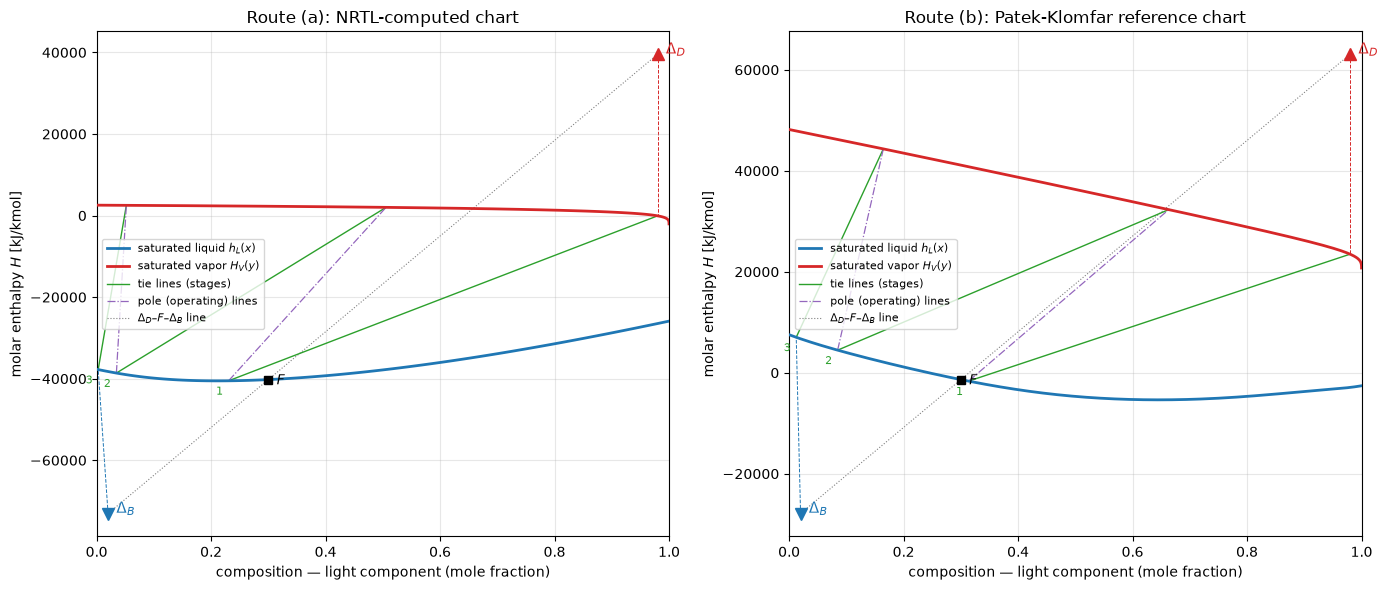

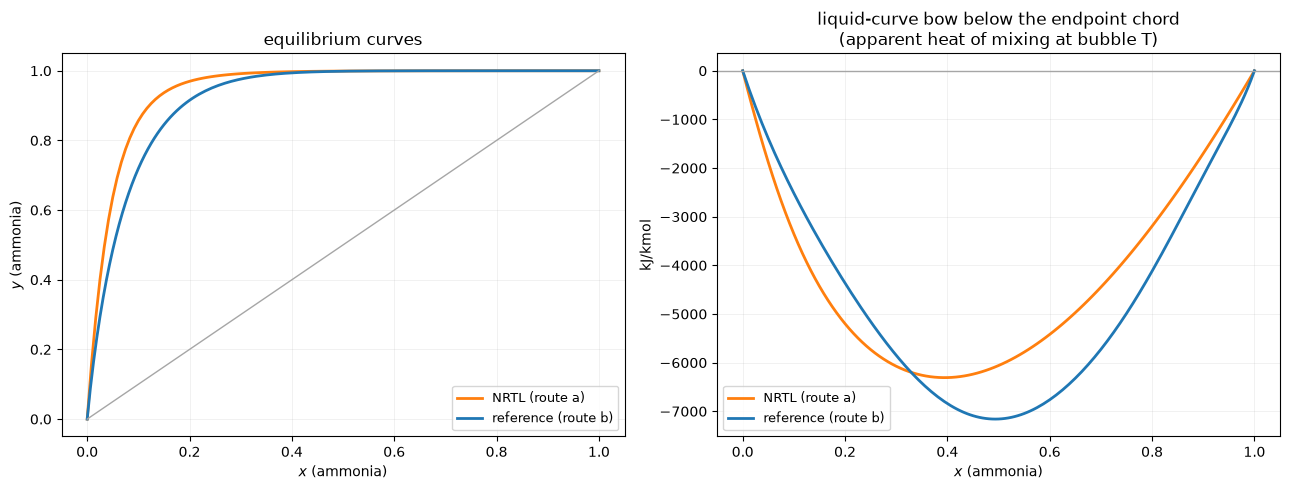

In [15]:
# The two constructions side by side (each chart keeps its own enthalpy datum).
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plotting.plot_ponchon_savarit(ps_a, ec_a, ax=axes[0])
axes[0].set_title("Route (a): NRTL-computed chart")
plotting.plot_ponchon_savarit(ps_b, ec_b, ax=axes[1])
axes[1].set_title("Route (b): Patek-Klomfar reference chart")
plt.tight_layout()
plt.show()

# Where do the charts actually differ? Compare the tie lines (VLE) and the bow of the
# liquid curve (the apparent heat of mixing) -- datum-free quantities.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(ec_a.x, ec_a.y, lw=2, color="tab:orange", label="NRTL (route a)")
ax1.plot(x_ref, y_ref, lw=2, color="tab:blue", label="reference (route b)")
ax1.plot([0, 1], [0, 1], color="0.65", lw=1)
ax1.set(xlabel="$x$ (ammonia)", ylabel="$y$ (ammonia)", title="equilibrium curves")
ax1.grid(alpha=0.25, lw=0.5)
ax1.legend(fontsize=9)

xa = np.array(ec_a.x)
hLa = np.array(ec_a.h_liq)
bow_a = hLa - (xa * hLa[-1] + (1 - xa) * hLa[0])
bow_b = hL_ref - (x_ref * hL_ref[-1] + (1 - x_ref) * hL_ref[0])
ax2.plot(xa, bow_a, lw=2, color="tab:orange", label="NRTL (route a)")
ax2.plot(x_ref, bow_b, lw=2, color="tab:blue", label="reference (route b)")
ax2.axhline(0.0, color="0.65", lw=1)
ax2.set(xlabel="$x$ (ammonia)", ylabel="kJ/kmol",
        title="liquid-curve bow below the endpoint chord\n(apparent heat of mixing at bubble T)")
ax2.grid(alpha=0.25, lw=0.5)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

### The gap is the lesson

Put the two constructions side by side and the surprise is *where* the model error lives:

- **The duties barely move.** $Q_R/F$ agrees to about 1% between the NRTL chart and the
  reference chart. The energy balance is dominated by the pure-component latent heats, which
  both charts carry essentially correctly, and even the bow of the liquid curve — the heat of
  mixing — comes out close (right panel above).
- **The tie lines do move.** At the water-rich end the NRTL vapor line is visibly too
  optimistic — at $x = 0.05$ it promises $y^\ast = 0.64$ where the data say 0.49 — so route
  (a) under-counts the stages (2.46 vs 2.90) and even puts the feed on the wrong stage
  (1 vs 2).

And McCabe–Thiele run on the same reference VLE still cannot produce a duty at all. So the
honest way to reproduce the textbook ammonia–water design is route (b): real chart, exact
construction — which is precisely how Ponchon and Savarit themselves ran it in 1921, minus
the straightedge.

In [16]:
# Pinned expectations for the two routes.
assert abs(ps_a.n_stages - 2.46) < 0.1, ps_a.n_stages
assert abs(ps_b.n_stages - 2.90) < 0.1, ps_b.n_stages
assert ps_a.feed_stage == 1 and ps_b.feed_stage == 2       # NRTL misplaces the feed stage
assert abs(ps_b.q_reboiler / ps_a.q_reboiler - 1) < 0.02   # duties agree to ~1%
assert ps_a.q_condenser > 0 and ps_a.q_reboiler > 0        # physically signed
assert mt_b.n_stages < ps_b.n_stages                       # CMO under-counts on the real chart
# NRTL's too-optimistic water-end VLE, quantified:
y_nrtl = np.interp(0.05, np.array(ec_a.x), np.array(ec_a.y))
assert y_nrtl - pk_y(P_MPA, np.array([0.05]))[0] > 0.10
print("OK — reference chart: duties agree to ~1%, tie lines don't (+0.44 stages, feed stage "
      "1 -> 2); M-T still can't answer the energy question.")

OK — reference chart: duties agree to ~1%, tie lines don't (+0.44 stages, feed stage 1 -> 2); M-T still can't answer the energy question.


## Exercises

Two exercises. Templates first; worked solutions are collapsed at the bottom.

### Exercise 1 — reflux vs energy

More reflux buys fewer stages but costs more heat. For **benzene–toluene** (`ec_bt`, spec
$x_D=0.95$, $x_B=0.05$, $z_F=0.50$), compute the Ponchon–Savarit stage count $N$ and the reboiler
duty $Q_R/F$ at $R = 1.2,\ 1.5,\ 2.0,\ 3.0 \times R_{min}$, and confirm $N$ falls while $Q_R/F$ rises.

### Exercise 2 — how big is the CMO error?

For **methanol–water** (`ec_mw`), compute the Ponchon–Savarit vs McCabe–Thiele stage gap at feed
compositions $z_F \in \{0.30,\ 0.50,\ 0.70\}$ (same $x_D, x_B, R$). Report where CMO is worst.

In [17]:
# Exercise 1 — TODO: fill in.
# r_min_bt = stages.rmin(eq_bt, 0.95, 0.05, 0.50).r_min
# for factor in (1.2, 1.5, 2.0, 3.0):
#     R = factor * r_min_bt
#     res = stages.ponchon_savarit(ec_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)
#     print(f"R = {factor:.1f} R_min:  N = {res.n_stages:.2f},  Q_R/F = {res.q_reboiler:,.0f} kJ/kmol")


In [18]:
# Exercise 2 — TODO: fill in.
# for zf in (0.30, 0.50, 0.70):
#     ps = stages.ponchon_savarit(ec_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
#     mt = stages.mccabe_thiele(eq_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
#     print(f"z_F = {zf:.2f}:  P-S {ps.n_stages:.2f}  M-T {mt.n_stages:.2f}  gap {ps.n_stages-mt.n_stages:+.2f}")


<details>
<summary><b>Solutions</b> (click to expand)</summary>

```python
# Exercise 1 — reflux vs energy (benzene-toluene)
r_min_bt = stages.rmin(eq_bt, 0.95, 0.05, 0.50).r_min
prev_N, prev_Q = None, None
for factor in (1.2, 1.5, 2.0, 3.0):
    R = factor * r_min_bt
    res = stages.ponchon_savarit(ec_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)
    print(f"R = {factor:.1f} R_min:  N = {res.n_stages:5.2f},  Q_R/F = {res.q_reboiler:,.0f} kJ/kmol")
    if prev_N is not None:
        assert res.n_stages < prev_N        # more reflux -> fewer stages
        assert res.q_reboiler > prev_Q      # more reflux -> more boil-up -> more duty
    prev_N, prev_Q = res.n_stages, res.q_reboiler

# Exercise 2 — the CMO error vs feed composition (methanol-water)
for zf in (0.30, 0.50, 0.70):
    ps = stages.ponchon_savarit(ec_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
    mt = stages.mccabe_thiele(eq_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
    print(f"z_F = {zf:.2f}:  P-S {ps.n_stages:5.2f}  M-T {mt.n_stages:5.2f}  gap {ps.n_stages-mt.n_stages:+.2f}")
# The gap is a genuine (small but nonzero) CMO error at every feed composition.
```

</details>

## References

- **Method:** Ponchon (*La Technique Moderne* **1921**), Savarit (*Arts et Métiers* **1922**);
  Seader, Henley & Roper, *Separation Process Principles*, Ch. 7. Theory as implemented:
  [`docs/theory/ponchon-savarit.md`](../docs/theory/ponchon-savarit.md).
- **NRTL liquid model:** Renon & Prausnitz, *AIChE J.* **1968**, 14, 135 (in vle-thermo).
- **Ammonia–water charts:** Merkel & Bošnjaković (1929); Bošnjaković (1935); Ibrahim & Klein,
  *ASHRAE Trans.* **1993**, 99(1), 1495; Tillner-Roth & Friend, *J. Phys. Chem. Ref. Data*
  **1998**, 27, 63. Full list + the "UNIQUAC trap" discussion:
  [`docs/references.md`](../docs/references.md).
- **Route (b) digitized reference data:** Pátek, J.; Klomfar, J. Simple functions for fast
  calculations of selected thermodynamic properties of the ammonia–water system. *Int. J.
  Refrig.* **1995**, 18(4), 228–234.
- **Acetone–water van Laar constants** (worked example 3): representative 1 atm fit,
  $A_{12} = 2.0400$, $A_{21} = 1.5019$ (infinite-dilution activity coefficients ≈ 7.7 and
  4.5, in the range reported for this system).
- **Algorithm design:** `PLAN.md` §4–§5 (the pedagogical ladder); code in
  [`engine/src/binary/ponchon_savarit.rs`](../engine/src/binary/ponchon_savarit.rs).